<a href="https://colab.research.google.com/github/vaishnavye/A.V.E.R.A/blob/main/AVERA_FRONT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
# Install required packages
!pip install -q google-genai pandas numpy matplotlib seaborn jinja2


In [53]:
import os, io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from datetime import date
from jinja2 import Template
from google.colab import userdata
import google.generativeai as genai # Standardized import for google.generativeai
from google.generativeai import GenerationConfig, types # Import GenerationConfig for model configuration
from google.colab import files

warnings.filterwarnings('ignore')

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY

genai.configure(api_key=GEMINI_API_KEY) # Configure API key globally
print("✅ Gemini API configured")


✅ Gemini API configured


In [54]:
# CAS PP Auto — current dataset
uploaded = files.upload()

# Replace with the exact filename you uploaded
df = pd.read_csv("ppauto_pos.csv")

# Preview the first 5 rows
df.head()


# Use df directly as your dataset
RAW_DF = df
print(f"✅ Loaded: {RAW_DF.shape[0]:,} rows, {RAW_DF.shape[1]} columns")
print(f"Columns : {RAW_DF.columns.tolist()}")
print(f"Companies: {RAW_DF['GRCODE'].nunique()} unique GRCODEs")
RAW_DF.head(3)

#############################



Saving ppauto_pos.csv to ppauto_pos (2).csv
✅ Loaded: 13,250 rows, 13 columns
Columns : ['GRCODE', 'GRNAME', 'AccidentYear', 'DevelopmentYear', 'DevelopmentLag', 'IncurredLosses', 'CumPaidLoss', 'BulkLoss', 'EarnedPremDIR', 'EarnedPremCeded', 'EarnedPremNet', 'Single', 'PostedReserves2007']
Companies: 143 unique GRCODEs


,GRCODE,GRNAME,AccidentYear,DevelopmentYear,DevelopmentLag,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremDIR,EarnedPremCeded,EarnedPremNet,Single,PostedReserves2007
0,43,IDS Property Cas Ins Co,1998,1998,1,50320,12762,21720,63709,3071,60638,0,277117.746
1,43,IDS Property Cas Ins Co,1998,1999,2,41036,26291,6514,63709,3071,60638,0,277117.746
2,43,IDS Property Cas Ins Co,1998,2000,3,39688,32420,2858,63709,3071,60638,0,277117.746


In [55]:
GRCODE = RAW_DF['GRCODE'].unique()[0]
company_df   = RAW_DF[RAW_DF['GRCODE'] == GRCODE].copy()
# Ensure 'AccidentYear' and 'DevelopmentLag' are numeric
company_df['AccidentYear'] = pd.to_numeric(company_df['AccidentYear'], errors='coerce')
company_df['DevelopmentLag'] = pd.to_numeric(company_df['DevelopmentLag'], errors='coerce')

COMPANY_NAME = company_df['GRNAME'].iloc[0]
print(f'Auditing: [{GRCODE}]  {COMPANY_NAME}')
print(f'Rows     : {len(company_df)}')
print(f'Accident years: {sorted(company_df["AccidentYear"].unique())}')
print(f'Dev lags      : {sorted(company_df["DevelopmentLag"].unique())}')

Auditing: [43]  IDS Property Cas Ins Co
Rows     : 100
Accident years: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007)]
Dev lags      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [56]:
print(company_df.columns.tolist())


['GRCODE', 'GRNAME', 'AccidentYear', 'DevelopmentYear', 'DevelopmentLag', 'IncurredLosses', 'CumPaidLoss', 'BulkLoss', 'EarnedPremDIR', 'EarnedPremCeded', 'EarnedPremNet', 'Single', 'PostedReserves2007']


In [57]:
#Core Triangle Helper

def build_triangle(field: str, mask_future: bool = True) -> pd.DataFrame:
    """
    Pivot the chosen company's data into an AccidentYear x DevelopmentLag matrix.
    When mask_future=True, cells in the lower triangle (not yet observed at
    the valuation date) are set to NaN — reflecting what an actuary would actually see.
    """
    # Use the field directly since your dataset has no suffix
    if field not in company_df.columns:
        raise KeyError(f"Column '{field}' not found. Available: {company_df.columns.tolist()}")

    # Drop rows with NaN in critical columns before pivoting
    df_clean = company_df.dropna(subset=['AccidentYear', 'DevelopmentLag'])

    # Aggregate duplicates before pivoting
    df_agg = df_clean.groupby(['AccidentYear', 'DevelopmentLag'])[field].sum().reset_index()

    tri = (df_agg
           .pivot(index="AccidentYear", columns="DevelopmentLag", values=field)
           .sort_index())

    if mask_future:
        eval_year = int(tri.index.max())
        for ay in tri.index:
            for dev in tri.columns:
                if int(ay) + int(dev) - 1 > eval_year:
                    tri.loc[ay, dev] = np.nan
    return tri

# Quick sanity check
paid_tri = build_triangle("CumPaidLoss")
print("Paid triangle shape:", paid_tri.shape)
print(paid_tri.head())

Paid triangle shape: (10, 10)
DevelopmentLag     1        2        3        4        5        6        7   \
AccidentYear                                                                  
1998            12762  26291.0  32420.0  36282.0  38260.0  39122.0  39786.0   
1999            15027  29449.0  36831.0  40756.0  43859.0  44499.0  45248.0   
2000            18464  36451.0  46230.0  50645.0  53094.0  53821.0  54024.0   
2001            25388  50321.0  62468.0  67086.0  68930.0  70899.0  71494.0   
2002            33620  67674.0  81853.0  88921.0  92669.0  94495.0      NaN   

DevelopmentLag       8        9        10  
AccidentYear                               
1998            39820.0  39876.0  39896.0  
1999            44993.0  45090.0      NaN  
2000            54236.0      NaN      NaN  
2001                NaN      NaN      NaN  
2002                NaN      NaN      NaN  


In [58]:
# Triangle Loader (Tool 1)
# Loads ans profiles  the Raw data : row count,accident years, dev lags, Premium, totals
#and snapshot of Triangles

LINE = 'ppauto'

def triangle_loader(line: str, grcode: int) -> dict:
    """Loads and profiles the PP Auto claims data for a specific company.
    Call this first before any other tool. Returns a data profile including
    shape, accident years, development lags, and earned premium summary.

    Args:
        line: Must be 'ppauto' for this notebook.
        grcode: The NAIC GRCODE of the company to audit.

    Returns:
        dict with keys: grname, rows, accident_years, dev_lags,
        total_earned_premium_net, avg_earned_premium_per_year, triangle_snapshot.
    """
    tri  = build_triangle('CumPaidLoss')
    prem = company_df.groupby('AccidentYear')['EarnedPremNet'].max()
    return {
        'grname'                  : COMPANY_NAME,
        'rows'                    : len(company_df),
        'accident_years'          : sorted(company_df['AccidentYear'].unique().tolist()),
        'dev_lags'                : sorted(company_df['DevelopmentLag'].unique().tolist()),
        'total_earned_premium_net': round(float(prem.sum()), 0),
        'avg_earned_premium_per_year': round(float(prem.mean()), 0),
        'triangle_snapshot'       : tri.fillna('').to_dict(),
    }

print(json.dumps({k:v for k,v in triangle_loader(LINE,GRCODE).items() if k!='triangle_snapshot'}, indent=2))

{
  "grname": "IDS Property Cas Ins Co",
  "rows": 100,
  "accident_years": [
    1998,
    1999,
    2000,
    2001,
    2002,
    2003,
    2004,
    2005,
    2006,
    2007
  ],
  "dev_lags": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "total_earned_premium_net": 1562178.0,
  "avg_earned_premium_per_year": 156218.0
}


In [59]:
#Completness Checker (Tool 2)

def completeness_checker(line: str, grcode: int) -> dict:
    """Checks whether the known (upper) part of the PP Auto paid-loss triangle has
    any missing (NaN) cells where data should exist.

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.

    Returns:
        dict with keys: status ('Green' or 'Red'), missing_count,
        missing_cells (list of [AccidentYear, DevelopmentLag]), summary.
    """
    tri        = build_triangle('CumPaidLoss')
    eval_year  = int(tri.index.max())
    missing    = []
    for ay in tri.index:
        for dev in tri.columns:
            if int(ay) + int(dev) - 1 <= eval_year and pd.isna(tri.loc[ay, dev]):
                missing.append([int(ay), int(dev)])
    status = 'Green' if not missing else 'Red'
    return {
        'status'       : status,
        'missing_count': len(missing),
        'missing_cells': missing,
        'summary'      : f'{len(missing)} missing cell(s) in the known triangle for GRCODE {grcode}.',
    }

print(completeness_checker(LINE, GRCODE))



{'status': 'Green', 'missing_count': 0, 'missing_cells': [], 'summary': '0 missing cell(s) in the known triangle for GRCODE 43.'}


In [60]:
#Sign Checker (Tool 3)
def sign_checker(line: str, grcode: int) -> dict:
    """Checks the PP Auto paid-loss triangle for negative incremental payments.
    Negative increments can indicate data errors, salvage/subrogation recoveries,
    or portfolio commutations and must be reviewed before any reserving analysis.

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.

    Returns:
        dict with keys: status ('Green' or 'Amber'), negative_count,
        negative_increments (list of [AccidentYear, DevelopmentLag, value]), summary.
    """
    cum_tri  = build_triangle('CumPaidLoss')
    inc_tri  = cum_tri.diff(axis=1)
    inc_tri[cum_tri.columns[0]] = cum_tri[cum_tri.columns[0]]
    negatives = []
    for ay in inc_tri.index:
        for dev in inc_tri.columns:
            val = inc_tri.loc[ay, dev]
            if pd.notna(val) and val < 0:
                negatives.append([int(ay), int(dev), round(float(val), 2)])
    status = 'Green' if not negatives else 'Amber'
    return {
        'status'             : status,
        'negative_count'     : len(negatives),
        'negative_increments': negatives,
        'summary'            : f'{len(negatives)} negative incremental paid-loss cell(s) for GRCODE {grcode}.',
    }

print(sign_checker(LINE, GRCODE))



{'status': 'Amber', 'negative_count': 1, 'negative_increments': [[1999, 8, -255.0]], 'summary': '1 negative incremental paid-loss cell(s) for GRCODE 43.'}


In [61]:
#Consistency Checker (Tool 4)
def consistency_checker(line: str, grcode: int) -> dict:
    """Checks that cumulative paid losses never exceed cumulative incurred losses
    (Paid > Incurred is theoretically impossible under standard GAAP/statutory
    accounting and signals a data integrity problem).

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.

    Returns:
        dict with keys: status ('Green' or 'Red'), violation_count,
        violations (list of [AccidentYear, DevelopmentLag, paid, incurred]), summary.
    """
    paid_tri    = build_triangle('CumPaidLoss')
    incurr_tri  = build_triangle('IncurredLosses')
    violations  = []
    for ay in paid_tri.index:
        for dev in paid_tri.columns:
            p = paid_tri.loc[ay, dev]
            i = incurr_tri.loc[ay, dev]
            if pd.notna(p) and pd.notna(i) and p > i + 1e-6:
                violations.append([int(ay), int(dev), round(float(p),2), round(float(i),2)])
    status = 'Green' if not violations else 'Red'
    return {
        'status'         : status,
        'violation_count': len(violations),
        'violations'     : violations,
        'summary'        : f'{len(violations)} cell(s) where Paid > Incurred for GRCODE {grcode}.',
    }

print(consistency_checker(LINE, GRCODE))

{'status': 'Red', 'violation_count': 1, 'violations': [[1999, 8, 44993.0, 44844.0]], 'summary': '1 cell(s) where Paid > Incurred for GRCODE 43.'}


In [62]:
#Outlier Detector (Tool 5)

def outlier_detector(line: str, grcode: int, z_threshold: float = 2.0) -> dict:
    """Computes age-to-age loss development factors (LDFs) for the PP Auto paid
    triangle and flags any single-company factor that deviates more than
    z_threshold standard deviations from the average factor for that development
    period across ALL companies in the dataset.

    Using the cross-company average (not just the single company) is more
    robust than comparing to the company's own history, especially for small
    portfolios. This is closer to how an actuary would benchmark LDFs.

    Args:
        line: Must be 'ppauto'.
        grcode: NAIC GRCODE to check.
        z_threshold: Standard deviations from mean to flag as outlier (default 2.0).

    Returns:
        dict with keys: status ('Green' or 'Amber'), outlier_count,
        outlier_factors (list of [AccidentYear, DevLag_from, company_ldf,
        industry_avg_ldf, z_score]), summary.
    """
    col      = 'CumPaidLoss'
    all_tri  = RAW_DF.copy()
    eval_yr  = int(RAW_DF['AccidentYear'].max())
    devs     = sorted(RAW_DF['DevelopmentLag'].unique())

    # ── compute cross-company LDF distribution per dev period ──────────────
    industry_ldfs = {}   # dev_from -> list of all-company LDFs
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i+1]
        sub_from = all_tri[all_tri['DevelopmentLag'] == d_from][['GRCODE','AccidentYear', col]].rename(columns={col:'from_val'})
        sub_to   = all_tri[all_tri['DevelopmentLag'] == d_to  ][['GRCODE','AccidentYear', col]].rename(columns={col:'to_val'})
        merged   = sub_from.merge(sub_to, on=['GRCODE','AccidentYear'])
        # mask future
        merged   = merged[merged['AccidentYear'] + d_to - 1 <= eval_yr]
        merged   = merged[(merged['from_val'] > 0) & (merged['to_val'] > 0)]
        if len(merged) >= 3:
            industry_ldfs[d_from] = merged['to_val'].values / merged['from_val'].values

    # ── compute this company's LDFs and compare ────────────────────────────
    comp_tri = build_triangle('CumPaidLoss')
    outliers = []
    for i in range(len(devs) - 1):
        d_from, d_to = devs[i], devs[i+1]
        if d_from not in industry_ldfs:
            continue
        ind_vals = industry_ldfs[d_from]
        mu, sigma = ind_vals.mean(), ind_vals.std()
        if sigma < 1e-9:
            continue
        for ay in comp_tri.index:
            num = comp_tri.loc[ay, d_to]  if d_to  in comp_tri.columns else np.nan
            den = comp_tri.loc[ay, d_from] if d_from in comp_tri.columns else np.nan
            if pd.notna(num) and pd.notna(den) and den > 0:
                ldf = num / den
                z   = (ldf - mu) / sigma
                if abs(z) > z_threshold:
                    outliers.append([int(ay), int(d_from), round(ldf,4), round(mu,4), round(z,2)])

    status = 'Green' if not outliers else 'Amber'
    return {
        'status'         : status,
        'outlier_count'  : len(outliers),
        'outlier_factors': outliers,
        'summary'        : (f'{len(outliers)} LDF outlier(s) found for GRCODE {grcode} '
                            f'vs cross-company benchmark (|z|>{z_threshold}).'),
    }

print(outlier_detector(LINE, GRCODE))

{'status': 'Green', 'outlier_count': 0, 'outlier_factors': [], 'summary': '0 LDF outlier(s) found for GRCODE 43 vs cross-company benchmark (|z|>2.0).'}


In [63]:
#Commentary writer
import time # Import time for sleep
import google.generativeai as genai
from google.api_core.exceptions import ClientError # Import ClientError from the correct location

def commentary_writer(check_name: str, check_result: dict) -> dict:
    """Generates a plain-English actuarial explanation for a single data-quality
    check result. Use this AFTER running each checker tool to produce the prose
    that will appear in the final Data Quality Report.

    Args:
        check_name: Name of the check (e.g. 'sign_checker', 'outlier_detector').
        check_result: The dict returned by the corresponding checker tool.

    Returns:
        dict with keys: check_name, status, commentary (2-4 sentence explanation
        suitable for inclusion in an actuarial working paper).
    """
    prompt = f"""You are an actuarial data-quality assistant writing commentary for
a Data Quality Report section. Write 2-4 sentences in professional actuarial language
explaining the following finding to a reserving actuary.

Check: {check_name}
Result: {json.dumps(check_result, indent=2)}

Rules:
- Do NOT just repeat the numbers. Explain what they mean actuarially.
- Mention why the finding matters (or doesn't) for reserving / IBNR estimation.
- If status is Green say so clearly and briefly.
- If Amber or Red, explain the risk and suggest one specific investigation step.
- Keep it under 80 words."""

    # Initialize the model within the function or ensure it's accessible globally
    model = genai.GenerativeModel(model_name='gemini-2.5-flash')

    try:
        resp = model.generate_content(
            contents=prompt,
            generation_config=genai.GenerationConfig(temperature=0.3, max_output_tokens=200)
        )
        commentary_text = resp.text.strip()
    except ClientError as e: # Catch ClientError from google.api_core.exceptions
        # Access the HTTP status code from the 'response' attribute of the exception
        if hasattr(e, 'response') and e.response.status_code == 429:
            print(f"Warning: API quota exceeded for {check_name}. Please wait and try again. Error: {e}")
            commentary_text = "API quota exceeded. Please wait and retry to generate commentary."
        else:
            print(f"Error generating commentary for {check_name}: {e}")
            commentary_text = f"Error generating commentary: {e}"
    except Exception as e:
        print(f"An unexpected error occurred for {check_name}: {e}")
        commentary_text = f"An unexpected error occurred: {e}"

    return {
        'check_name' : check_name,
        'status'     : check_result.get('status','Unknown'),
        'commentary' : commentary_text,
    }

# Quick test
# Add a small delay before the quick test if running immediately after other API calls
# time.sleep(2) # Uncomment this if you suspect hitting rate limits frequently
demo = commentary_writer('sign_checker', sign_checker(LINE, GRCODE))
print(demo['commentary'])


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 32.878923767s.
API quota exceeded. Please wait and retry to generate commentary.


In [64]:
#Report Compiler (Tool 7)
REPORT_TEMPLATE = """
# AVERA — Data Quality Report

| Field | Value |
|---|---|
| **Company** | {{ company_name }} (GRCODE {{ grcode }}) |
| **Line of Business** | Private Passenger Auto Liability/Medical (Schedule P) |
| **Report Date** | {{ report_date }} |
| **Overall Readiness** | {{ overall_verdict }} |

---

## Overall Verdict: {{ overall_verdict }}
{{ overall_rationale }}

---

## Findings by Check

{% for section in sections %}
### {{ loop.index }}. {{ section.title }} — {{ section.status }}

**Raw findings:** {{ section.raw_summary }}

**Actuarial commentary:** {{ section.commentary }}

{% endfor %}

---

## Recommended Next Steps
{% for step in next_steps %}
{{ loop.index }}. {{ step }}
{% endfor %}

---
*This report was generated by ClaimSense (Gemini 2.5 Flash agentic system). All findings are flagged for human review — the final decision to proceed with analysis rests with the responsible actuary.*
"""

def report_compiler(
    loader_result       : dict,
    completeness_result : dict,
    sign_result         : dict,
    consistency_result  : dict,
    outlier_result      : dict,
    commentaries        : list,
    next_steps          : list,
) -> dict:
    """Assembles all tool outputs into a formatted Markdown Data Quality Report.
    Call this as the FINAL step after all checkers and the commentary_writer
    have been run.

    Args:
        loader_result:       Output of triangle_loader.
        completeness_result: Output of completeness_checker.
        sign_result:         Output of sign_checker.
        consistency_result:  Output of consistency_checker.
        outlier_result:      Output of outlier_detector.
        commentaries:        List of dicts from commentary_writer (one per check).
        next_steps:          List of recommended action strings.

    Returns:
        dict with keys: report_markdown (full Markdown string), overall_verdict.
    """
    statuses = [
        completeness_result['status'],
        sign_result['status'],
        consistency_result['status'],
        outlier_result['status'],
    ]
    if 'Red'   in statuses: overall = '🔴 RED — Data Not Ready'
    elif 'Amber' in statuses: overall = '🟡 AMBER — Proceed With Caution'
    else:                     overall = '🟢 GREEN — Data Ready'

    comm_map = {c['check_name']: c['commentary'] for c in commentaries}

    sections = [
        {'title':'Completeness Check',     'status': completeness_result['status'],
         'raw_summary': completeness_result['summary'],
         'commentary' : comm_map.get('completeness_checker','')},
        {'title':'Sign Check',             'status': sign_result['status'],
         'raw_summary': sign_result['summary'],
         'commentary' : comm_map.get('sign_checker','')},
        {'title':'Paid vs Incurred Check', 'status': consistency_result['status'],
         'raw_summary': consistency_result['summary'],
         'commentary' : comm_map.get('consistency_checker','')},
        {'title':'LDF Outlier Detection',  'status': outlier_result['status'],
         'raw_summary': outlier_result['summary'],
         'commentary' : comm_map.get('outlier_detector','')},
    ]

    overall_rationale = (f'Out of 4 checks, '
        f'{statuses.count("Red")} returned Red, '
        f'{statuses.count("Amber")} returned Amber, '
        f'{statuses.count("Green")} returned Green.')

    report_md = Template(REPORT_TEMPLATE).render(
        company_name     = COMPANY_NAME,
        grcode           = GRCODE,
        report_date      = date.today().isoformat(),
        overall_verdict  = overall,
        overall_rationale= overall_rationale,
        sections         = sections,
        next_steps       = next_steps,
    )
    return {'report_markdown': report_md, 'overall_verdict': overall}

print('✅ report_compiler defined')



✅ report_compiler defined


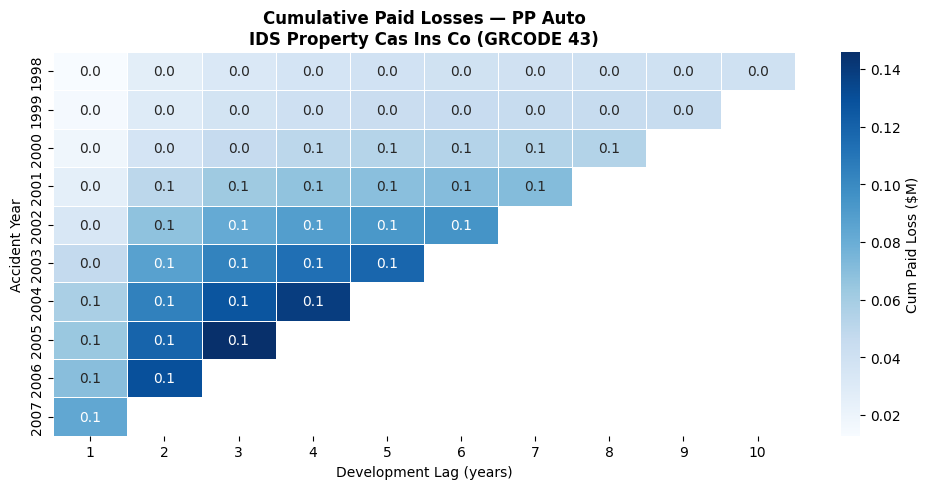

Saved: paid_triangle.png


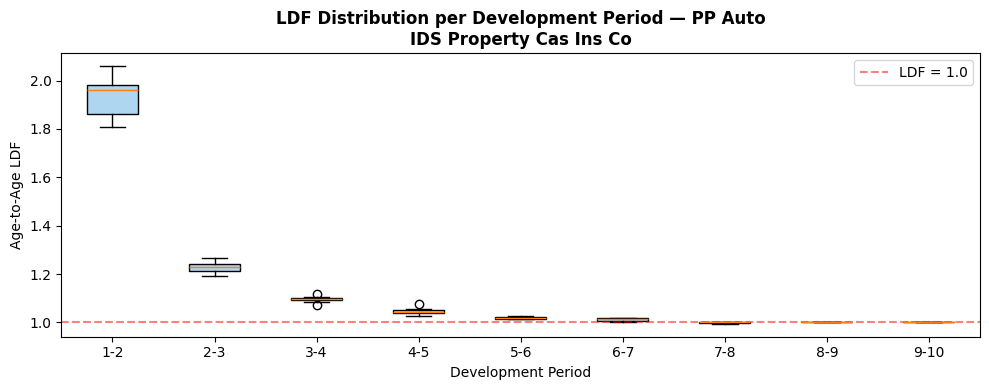

Saved: ldf_boxplot.png


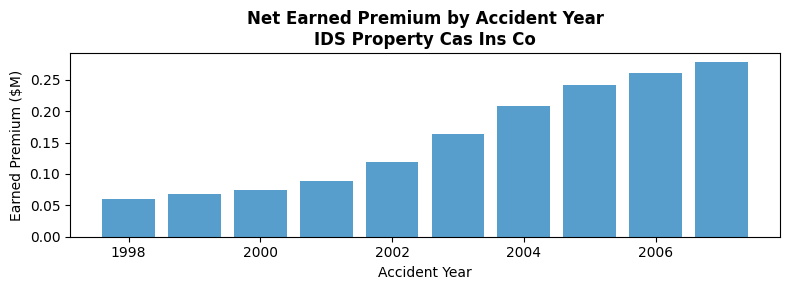

Saved: premium_trend.png


In [65]:
# Visualise the Triangle
#These plots apear in the report appendix and make excellent interaction
def plot_paid_triangle():
    tri = build_triangle('CumPaidLoss')
    fig, ax = plt.subplots(figsize=(10, 5))
    mask = tri.isna()
    sns.heatmap(tri/1e6, mask=mask, annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax, cbar_kws={'label':'Cum Paid Loss ($M)'})
    ax.set_title(f'Cumulative Paid Losses — PP Auto\n{COMPANY_NAME} (GRCODE {GRCODE})', fontweight='bold')
    ax.set_xlabel('Development Lag (years)')
    ax.set_ylabel('Accident Year')
    plt.tight_layout()
    plt.savefig('paid_triangle.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: paid_triangle.png')

def plot_ldf_boxplot():
    tri  = build_triangle('CumPaidLoss')
    devs = sorted(tri.columns)
    ldf_data, labels = [], []
    for i in range(len(devs)-1):
        d_from, d_to = devs[i], devs[i+1]
        ratios = []
        for ay in tri.index:
            n, d = tri.loc[ay, d_to], tri.loc[ay, d_from]
            if pd.notna(n) and pd.notna(d) and d > 0:
                ratios.append(n/d)
        if ratios:
            ldf_data.append(ratios)
            labels.append(f'{d_from}-{d_to}')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(ldf_data, labels=labels, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'))
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='LDF = 1.0')
    ax.set_title(f'LDF Distribution per Development Period — PP Auto\n{COMPANY_NAME}', fontweight='bold')
    ax.set_xlabel('Development Period')
    ax.set_ylabel('Age-to-Age LDF')
    ax.legend()
    plt.tight_layout()
    plt.savefig('ldf_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: ldf_boxplot.png')

def plot_premium_trend():
    prem = company_df.groupby('AccidentYear')['EarnedPremNet'].max()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(prem.index, prem.values/1e6, color='#2E86C1', alpha=0.8)
    ax.set_title(f'Net Earned Premium by Accident Year\n{COMPANY_NAME}', fontweight='bold')
    ax.set_xlabel('Accident Year')
    ax.set_ylabel('Earned Premium ($M)')
    plt.tight_layout()
    plt.savefig('premium_trend.png', dpi=150)
    plt.show()
    print('Saved: premium_trend.png')

plot_paid_triangle()
plot_ldf_boxplot()
plot_premium_trend()

In [67]:
import time
import google.generativeai as genai
from google.generativeai import GenerationConfig, types

# Run All Tools & compile the Full Report
print('=' * 60)
print('AVERA — Full Audit Pipeline Starting')
print('=' * 60)

# ── 1. Load & profile ─────────────────────────────────────────
print('\n[1/6] Running triangle_loader...')
loader_res = triangle_loader(LINE, GRCODE)
print(f'      Accident years: {loader_res["accident_years"]}')
print(f'      Total net premium: ${loader_res["total_earned_premium_net"]:,.0f}')

# ── 2. Quality checks ─────────────────────────────────────────
print('\n[2/6] Running completeness_checker...')
comp_res = completeness_checker(LINE, GRCODE)
print(f'      {comp_res["status"]} — {comp_res["summary"]}')

print('\n[3/6] Running sign_checker...')
sign_res = sign_checker(LINE, GRCODE)
print(f'      {sign_res["status"]} — {sign_res["summary"]}')

print('\n[4/6] Running consistency_checker...')
cons_res = consistency_checker(LINE, GRCODE)
print(f'      {cons_res["status"]} — {cons_res["summary"]}')

print('\n[5/6] Running outlier_detector...')
out_res  = outlier_detector(LINE, GRCODE)
print(f'      {out_res["status"]} — {out_res["summary"]}')

# ── 3. commentary_writer for each check ───────────────────────
print('\n[6/6] Running commentary_writer for each check...')
all_checks = [
    ('completeness_checker', comp_res),
    ('sign_checker',         sign_res),
    ('consistency_checker',  cons_res),
    ('outlier_detector',     out_res),
]
commentaries = []
for name, result in all_checks:
    c = commentary_writer(name, result)
    commentaries.append(c)
    print(f'      ✅ {name}')
    time.sleep(1)   # small pause to respect free-tier rate limits

# ── 4. Generate next steps via Gemini ─────────────────────────
print('\nGenerating recommended next steps...')
all_summaries = '\n'.join([r['summary'] for _, r in all_checks])
ns_prompt = f"""Based on these data quality findings for a PP Auto loss triangle:
{all_summaries}
List exactly 4 concise, actionable next steps for the reserving actuary.
Format as a plain numbered list. No headers. Each step under 20 words."""

# Initialize the model for next steps generation
model_for_next_steps = genai.GenerativeModel(model_name='gemini-2.5-flash')

ns_resp  = model_for_next_steps.generate_content(
    contents=ns_prompt,
    generation_config=genai.GenerationConfig(temperature=0.2, max_output_tokens=200)
)
next_steps = [line.strip().lstrip('1234567890. ').strip()
              for line in ns_resp.text.strip().split('\n') if line.strip()][:4]

# ── 5. Compile final report ───────────────────────────────────
print('\nCompiling final Data Quality Report...')
report = report_compiler(
    loader_result       = loader_res,
    completeness_result = comp_res,
    sign_result         = sign_res,
    consistency_result  = cons_res,
    outlier_result      = out_res,
    commentaries        = commentaries,
    next_steps          = next_steps,
)

print('\n' + '=' * 60)
print(f'OVERALL VERDICT: {report["overall_verdict"]}')
print('=' * 60)


AVERA — Full Audit Pipeline Starting

[1/6] Running triangle_loader...
      Accident years: [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]
      Total net premium: $1,562,178

[2/6] Running completeness_checker...
      Green — 0 missing cell(s) in the known triangle for GRCODE 43.

[3/6] Running sign_checker...
      Amber — 1 negative incremental paid-loss cell(s) for GRCODE 43.

[4/6] Running consistency_checker...
      Red — 1 cell(s) where Paid > Incurred for GRCODE 43.

[5/6] Running outlier_detector...
      Green — 0 LDF outlier(s) found for GRCODE 43 vs cross-company benchmark (|z|>2.0).

[6/6] Running commentary_writer for each check...


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 51.209479731s.
      ✅ completeness_checker
An unexpected error occurred for sign_checker: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
      ✅ sign_checker


* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 48.72652166s.
      ✅ consistency_checker
An unexpected error occurred for outlier_detector: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
      ✅ outlier_detector

Generating recommended next steps...


TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 46.254569645s.

In [68]:
# Display and Save Report
from IPython.display import Markdown, display
display(Markdown(report['report_markdown']))



NameError: name 'report' is not defined

In [ ]:
# Save as Markdown file (download from Colab file browser on the left)
fname = f'DQR_PPAuto_{GRCODE}_{date.today().isoformat()}.md'
with open(fname, 'w') as f:
    f.write(report['report_markdown'])
print(f'✅ Report saved as: {fname}')
print('   Download it from the folder icon in the left sidebar.')


In [ ]:
#AUDITING MULTIPLE COMPANIES AT A TIME

# Loop over the several GDCODEs and compare thier readiness verdict in a summary table.
# Set how many companies to audit (keep low on free tier to avoid rate limits)
N_COMPANIES = 5

sample_codes = RAW_DF['GRCODE'].unique()[:N_COMPANIES]
summary_rows = []

for gc in sample_codes:
    comp_r = completeness_checker(LINE, int(gc))
    sign_r = sign_checker(LINE, int(gc))
    cons_r = consistency_checker(LINE, int(gc))
    out_r  = outlier_detector(LINE, int(gc))
    statuses = [comp_r['status'], sign_r['status'], cons_r['status'], out_r['status']]
    if 'Red' in statuses:     verdict = '🔴 RED'
    elif 'Amber' in statuses: verdict = '🟡 AMBER'
    else:                     verdict = '🟢 GREEN'
    gname = RAW_DF[RAW_DF['GRCODE'] == gc]['GRNAME'].iloc[0]
    summary_rows.append({
        'GRCODE'       : gc,
        'Company'      : gname[:35],
        'Completeness' : comp_r['status'],
        'Sign'         : sign_r['status'],
        'Paid≤Incurred': cons_r['status'],
        'LDF Outliers' : out_r['status'],
        'Verdict'      : verdict,
    })
    time.sleep(0.5)

summary_df = pd.DataFrame(summary_rows)
print('\nMulti-Company Readiness Summary')
print('=' * 80)
print(summary_df.to_string(index=False))
